![NVIDIA Logo](images/nvidia.png)

# Simple Pipelines With Output Sinks

In this notebook we will create our first pipeline with multiple stages. In doing so you'll learn how to connect stages together in a linear pipeline, and begin exploring how Morpheus uses **messages** to communicate between stages in a pipeline.

---

## Objectives

By the time you complete this notebook you will be able to:

- Create a multi-stage linear pipeline.
- Work with Morpheus's `MessageMeta` message type.

---

## Imports

The following imports are used in this notebook. We will look at each of them individually as they are used in code.

In [1]:
import logging

from IPython.display import Image

from morpheus.config import Config
from morpheus.pipeline import LinearPipeline

from morpheus.stages.general.monitor_stage import MonitorStage
from morpheus.stages.input.file_source_stage import FileSourceStage
from morpheus.stages.output.in_memory_sink_stage import InMemorySinkStage
from morpheus.stages.output.write_to_file_stage import WriteToFileStage

from morpheus.utils.logger import configure_logging, reset_logging

---

## Anatomy of a Pipeline

![anatomy-of-a-pipeline](images/anatomy-of-a-pipeline.png)

Pipelines are composed of a collection of stages, connected together via edges, all working toward a specific goal.

In the previous notebook you created a pipeline with only its single necessary stage, a source stage. In this notebook you will begin to construct pipelines comprised of multiple stages.

---

## Create a Config Object

As in the previous notebook, we start with the creation of a `config` object, again in the most simple-manner possible.

In [2]:
config = Config()

---

## Create a Linear Pipeline

Also as in the previous notebook, we create a linear pipeline, passing it our `config` object.

In [3]:
pipeline = LinearPipeline(config)

---

## Create Pipeline Source Stage

As in the previous notebook, we will create a source stage for our pipeline by reading from file a small collection of simple synthetic user authentication logs.

In [4]:
input_file = 'data/simple_user_log.jsonlines'

In [5]:
pipeline.set_source(FileSourceStage(config, filename=input_file, iterative=False, repeat=100))

<from-file-0; FileSourceStage(filename=data/simple_user_log.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=100, filter_null=True, filter_null_columns=None, parser_kwargs=None)>

## Adding a Monitoring Stage

During development, it can be useful to add monitoring stages to visualize the throughput at various stages, we add a `MonitorStage` here. During runtime, Morpheus will make scheduling decisions to optimize performance. 

With the default settings for this stage, you will typically see throughput reach an equilibrium value across all included Monitoring stages. There are other settings, that can be used, depending on your use case and pipeline setup.

In [6]:
print(MonitorStage.__doc__)


    Display throughput numbers at a specific point in the pipeline.

    Monitor stage used to monitor stage performance metrics using Tqdm. Each Monitor Stage will represent one
    line in the console window showing throughput statistics. Can be set up to show an instantaneous
    throughput or average input.

    Parameters
    ----------
    c : `morpheus.config.Config`
        Pipeline configuration instance.
    description : str, default = "Progress"
        Name to show for this Monitor Stage in the console window.
    smoothing : float
        Smoothing parameter to determine how much the throughput should be averaged. 0 = Instantaneous, 1 =
        Average.
    unit : str
        Units to show in the rate value.
    delayed_start : bool
        When delayed_start is enabled, the progress bar will not be shown until the first message is received.
        Otherwise, the progress bar is shown on pipeline startup and will begin timing immediately. In large pipelines,
        thi

In [7]:
pipeline.add_stage(MonitorStage(config, description="From file rate"))

<monitor-1; MonitorStage(description=From file rate, smoothing=0.05, unit=messages, delayed_start=False, determine_count_fn=None, log_level=LogLevels.INFO)>

---

## Create In-Memory Sink Stage

We are now going to create a second stage using `morpheus.stages.output.in_memory_sink_stage.InMemorySinkStage`. This stage will store the messages emitted by the pipeline's previous stages into a Python variable, which we will here call `in_mem_sink`.

In [8]:
in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))

---

## Combining Stages in a Linear Pipeline

Because our pipeline was instantiated using `LinearPipeline`, which can only ever support the linear passing of data from one stage to one other stage, even if there are many stages in a linear progression, all we have to do to "connect" one stage to another is to use the pipeline's `add_stage` method, as we have done in this notebook.

---

## Build the Pipeline

Let's build our new pipeline and as we did in the previous notebook, visulize it.

In [9]:
pipeline.build()

In [10]:
viz_file = './pipeline_visualizations/simple_sink.png'
pipeline.visualize(viz_file)

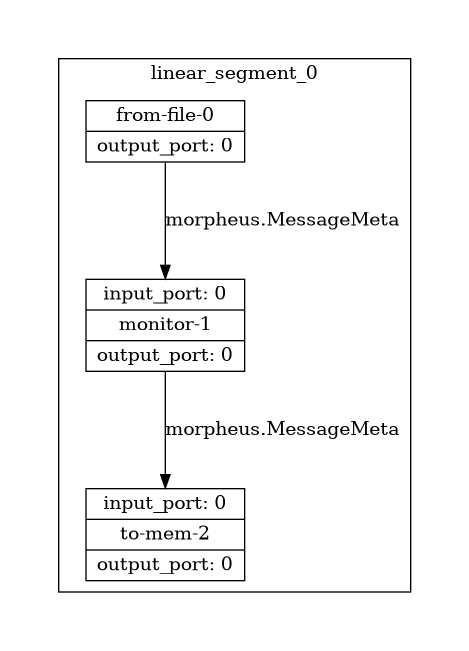

In [11]:
Image(filename=viz_file)

In [12]:
!morpheus run pipeline-fil from-file --filename=$input_file monitor to-file --filename=output.jsonlines --overwrite

Configuring Pipeline via CLI
Starting pipeline via CLI... Ctrl+C to Quit


In [13]:
!morpheus run --help

Usage: morpheus run [OPTIONS] COMMAND [ARGS]...

  Run subcommand, used for running a pipeline

Options:
  --num_threads INTEGER RANGE     Number of internal pipeline threads to use
                                  [default: 24; x>=1]
  --pipeline_batch_size INTEGER RANGE
                                  Internal batch size for the pipeline. Can be
                                  much larger than the model batch size. Also
                                  used for Kafka consumers  [default: 256;
                                  x>=1]
  --model_max_batch_size INTEGER RANGE
                                  Max batch size to use for the model
                                  [default: 8; x>=1]
  --edge_buffer_size INTEGER RANGE
                                  The size of buffered channels to use between
                                  nodes in a pipeline. Larger values reduce
                                  backpressure at the cost of memory. Smaller
                        

As you can see, our pipeline now consists of two stages: `from-file-0` and `to-mem-1`. These stages are connected by an edge (represented by the arrow) over which messages are passed. In the case of our pipeline, the kind of message being passed is `MessageMeta`, which is a simple message type in Morpheus which for now you can think of as a cuDF dataframe.

Stages in Morpheus are strict about the types of messages they send and receive, and as our pipelines get more complex, we will need to be intentional about the types of messages they send or receive.

For now we are working with stages that expect and send `MessageMeta` messages, so everthing is going to work for us without the need to be more intentional about message types.

---

## Run the Pipeline

Let's set up logging, and run the pipeline.

In [14]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

====Starting Pipeline====
====Building Segment: linear_segment_0====
Added source: <from-file-0; FileSourceStage(filename=data/simple_user_log.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=100, filter_null=True, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta
Added stage: <monitor-1; MonitorStage(description=From file rate, smoothing=0.05, unit=messages, delayed_start=False, determine_count_fn=None, log_level=LogLevels.INFO)>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta


Added stage: <to-mem-2; InMemorySinkStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta


====Pipeline Started====


====Building Segment Complete!====


From file rate: 0 messages [00:00, ? messages/s]

====Pipeline Complete====


In [15]:
await pipeline.run_async()

From file rate[Complete]: 1000 messages [00:01, 534.59 messages/s]


---

## View Messages in the Message Sink

Since we created a pipeline with an in-memory sink which we defined as `in_mem_sink`, we can view the messages that have passed through the pipeline via the sink using its `get_messages` method.

In [16]:
messages = in_mem_sink.get_messages()

Our sink only contains a single message containing the single dataframe created from our file source.

In [17]:
len(messages)

100

As mentioned this message is of the simple Morpheus message type `MessageMeta`.

In [18]:
message = messages[0]

In [19]:
type(message)

morpheus._lib.messages.MessageMeta

We can view the underlying dataframe of a `MessageMeta` using the `get_data()` method.

In [20]:
df = message.get_data()

In [21]:
type(df)

cudf.core.dataframe.DataFrame

In [22]:
df

,timestamp,user,ip_address,request_time,status,error_message
0,2025-02-01T10:15:30Z,user123,192.168.1.10,200.45,success,<NA>
1,2025-02-01T10:17:00Z,user123,192.168.1.20,150.55,failure,Invalid credentials
2,2025-02-01T10:18:10Z,user456,10.0.0.5,180.60,success,<NA>
3,2025-02-01T10:19:25Z,user789,192.168.1.30,215.25,failure,Timeout
4,2025-02-01T10:20:00Z,user456,10.0.0.6,120.10,success,<NA>
5,2025-02-01T10:22:30Z,user123,192.168.1.40,175.35,failure,Access denied
6,2025-02-01T10:23:45Z,user321,192.168.1.50,205.50,success,<NA>
7,2025-02-01T10:25:05Z,user864,192.168.1.60,190.15,failure,Invalid session
8,2025-02-01T10:26:20Z,user123,192.168.1.70,210.80,success,<NA>
9,2025-02-01T10:27:40Z,user456,10.0.0.7,160.95,failure,Account locked


In [ ]:
#1. config 객체 생성
#2. pipeline 객체 생성
#3. source(input) 추가 (출발)
#4. general 추가
#5. output 추가
#6. pipeline.build() 완료 선언
#7. pipeline.visualize() 시각화
#8. reset_logging(), configure_logging(log_level)
#9. await pipeline.run_async() 실행